In [27]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

In [28]:
recipes_df = pd.read_csv("./data/recipes.csv")

def getmeals(recipes_df):
    meals = {}
    for _, row in recipes_df.iterrows():
       meals.update({ 
          row["Name"]:(
          row["type"],
          row["Category"],
          row["total_price"],
          row["provided_calories"]
       )})
    return meals

def gettransitionModel(recipes_df):
    result = {}

    for _, row in recipes_df.iterrows():
        meal_type = row["type"]
        name = row["Name"]

        if meal_type not in result:
            result[meal_type] = []

        result[meal_type].append(name)

    return result

def diversity_penalty_per_week(state):
    penalty = 0
    days_per_week = 7
    meals_per_day = 3

    for start in range(0, len(state), days_per_week):
        week = state[start:start + days_per_week]

        week_meals = [meal for day in week for meal in day]

        counts = {}
        for meal in week_meals:
            counts[meal] = counts.get(meal, 0) + 1

        for meal, count in counts.items():
            if count > 2:
                penalty += (count - 2)
    return penalty / (len(state) * meals_per_day)

class GAProblem:
    def __init__(self, recipes_df, total_price, tdee):
        self.meals = getmeals(recipes_df)
        self.size = 90
        self.total_price = total_price
        self.tdee = tdee
        self.transitionmodel = gettransitionModel(recipes_df)
    
    def get_total_cost(self, state):
        total_cost = 0
        for i in range(len(state)):
           breakfast_cost =  self.meals[state[i][0]][2]
           lunch_cost = self.meals[state[i][1]][2]
           dinner_cost  = self.meals[state[i][2]][2]
           day_cost = breakfast_cost+lunch_cost+dinner_cost
           total_cost += day_cost
        return total_cost
    
    def get_total_cal(self,state):
        day_calories = []
        for day in state:
            day_cal = (
            self.meals[day[0]][3] +
            self.meals[day[1]][3] +
            self.meals[day[2]][3]
        )
            if day_cal > self.tdee * 1.1 or day_cal < self.tdee * 0.9:
                print(day_cal)
                print("Out of calories range")
            day_calories.append(day_cal)
        
        return sum(day_calories)
   
    def fitness_function(self, state):
        total_cost = self.get_total_cost(state)
        cost_penalty = 1 if (self.total_price - total_cost) / (self.total_price) < 0 else (self.total_price - total_cost) / (self.total_price)
        lower_bound = 0.9 * self.tdee
        upper_bound = 1.1 * self.tdee

        bad_days = 0
        for day in state:
            day_calories = (
                self.meals[day[0]][3] +
                self.meals[day[1]][3] +
                self.meals[day[2]][3]
            )
            if day_calories != self.tdee:
                bad_days += 0.001
            if day_calories < lower_bound or day_calories > upper_bound:
                bad_days += 1
        nutrition_penalty = bad_days / len(state)
        diversity_penalty = diversity_penalty_per_week(state)
        fitness = -(
            0.4 * cost_penalty +
            0.45 * nutrition_penalty +
            0.15 * diversity_penalty
        )
        return fitness
    def generate_random_state(self):
         return [(random.choice(self.transitionmodel['Breakfast']),
                  random.choice(self.transitionmodel['Lunch']),
                  random.choice(self.transitionmodel['Dinner']))
                    for _ in range(30)]
def crossover_and_mutation(population,problem):
       childs = []
       for i in range(len(population)):
         for j in range(i+1,len(population)):
            cutoff = random.randrange(1,29)
            parent_a = population[i][0]
            parent_b = population[j][0]
            child_a = parent_a[:cutoff] + parent_b[cutoff:]
            child_b = parent_b[:cutoff] + parent_a[cutoff:]
            random_lunch_a = random.choice(problem.transitionmodel['Lunch'])
            random_lunch_b = random.choice(problem.transitionmodel['Lunch'])
            random_pos_a  = random.randrange(30)
            random_pos_b  = random.randrange(30)
            t1 =   [child_a[random_pos_a][0],random_lunch_a, child_a[random_pos_a][2]]
            t2 =  [child_b[random_pos_b][0],random_lunch_b, child_b[random_pos_b][2]]
            child_a[random_pos_a] = tuple(t1) 
            child_b[random_pos_b] = tuple(t2) 
            childs.append((child_a,problem.fitness_function(child_a)))
            childs.append((child_b,problem.fitness_function(child_b)))
       return childs


def GASearch(problem):
    # step 1 Selection:
    list_of_states = []
    for _ in range(100):
        state = problem.generate_random_state()
        fitness = problem.fitness_function(state)
        list_of_states.append((state,fitness))
    population = sorted(list_of_states, key=lambda x: x[1], reverse=True)[:25]
    # step 2 and 3 crossover and mutation
    for _ in range(1000):
        population = sorted(population, key=lambda x: x[1], reverse=True)[:25]
        for state, fitness in population:
            if fitness == 0:
                return (state, fitness)
        population =  crossover_and_mutation(population,problem)
    best_candidate = sorted(population, key=lambda x: x[1], reverse=True)[:1]
    return best_candidate[0]

In [29]:
g = GAProblem(recipes_df,30000,2000)
solution, fitness  = GASearch(g)
print(solution)
print(f"Fitness: {fitness}")
print(g.get_total_cost(solution))
print(g.get_total_cal(solution))

[('Beet Yogurt Breakfast Plate', 'Lentil Beef Bowl', 'Stuffed Pepper Rice'), ('Banana Almond Raib Bowl', 'Beef Mushroom Couscous', 'Daurade Zucchini Olive Dinner'), ('Breakfast Omelette', 'Chorba Hamra', 'Hchaichi'), ('Breakfast Omelette', 'Beef Pepper Rice Plate', 'Lamb Zucchini Dinner'), ('Shrimp Egg Herb Scramble', 'Lentil Beef Bowl', 'Dolma'), ('Sardine Breakfast Plate', 'Chorba el Djaj', 'Beef Chickpea Tomato Dinner'), ('Rice Porridge', 'Merlan Green Bean Plate', 'Shrimp Pepper Plate'), ('Protein Yogurt Crunch', 'Berkoukes', 'Shrimp Broccoli Plate'), ('Egg Oat Protein Pancakes', 'Shrimp Rice Bowl', 'Chicken Cauliflower Dinner'), ('Semolina Milk Honey Bowl', 'Mutton Chickpea Stew Bowl', 'Beef Pepper Stir Fry'), ('Lentil Tomato Breakfast Soup', 'Beef Pepper Rice Plate', 'Lamb Zucchini Dinner'), ('Beet Yogurt Breakfast Plate', 'Chicken Carrot Pea Bowl', 'Couscous Sardine Dinner'), ('Protein Smooth Bowl', 'Mutton Potato Onion Plate', 'Beef Mushroom Pasta'), ('Carrot Raisin Yogurt Bowl

In [30]:
g = GAProblem(recipes_df,20000,2000)
solution, fitness  = GASearch(g)
print(solution)
print(f"Fitness: {fitness}")
print(f"total cost is : {g.get_total_cost(solution)}")
print(f"total calories are : {g.get_total_cal(solution)}")

[("M'semen", 'Beef Cucumber Olive Bowl', 'Beef Loubia Stew'), ('Zucchini Herb Omelette', 'Couscous Beef Harissa', 'Shrimp Brocculi Stir Fry'), ('Harissa Egg Scramble', 'Tuna Salad Bowl', 'Vegetable Soup'), ('Harissa Sardine Egg Plate', 'Chicken Chickpea Bowl', 'Sardine Rice Coriander Dinner'), ('Chicken Egg Breakfast Bowl', 'Chickpea Tomato Coriander Bowl', 'Couscous Seffa'), ('Daurade Olive Breakfast Bowl', 'Shrimp Rice Bowl', 'Harira'), ('Cottage Cheese Berry Bowl', 'Chicken Spinach Rice', 'Spinach Chicken Plate'), ('Rice Porridge', 'Loubia Tomato Bowl', 'Chickpea Spinach Rice'), ('Spinach Cheese Egg Scramble', 'Chickpea Tomato Stew', 'Vegetable Couscous'), ('Harissa Egg Scramble', 'Chorba Frik', 'Lamb Zucchini Dinner'), ('Shrimp Egg Herb Scramble', 'Chickpea Tomato Stew', 'Lamb Chickpea Stew'), ('Beet Carrot Salad', 'Tajine Zitoun', 'Vegetable Couscous'), ('Orange Date Yogurt Bowl', 'Chorba Frik', 'Harira'), ('Fruit Salad', 'Beef Lettuce Bowl', 'Tuna Pasta'), ('Zucchini Herb Omelett

[('Daurade Olive Breakfast Bowl', 'Tchicha', 'Chicken Lentil Spinach Dinner'), ('Bourek', 'Chickpea Chicken Bowl', 'Dolma'), ('Beet Yogurt Breakfast Plate', 'Loubia Tomato Bowl', 'Couscous Sardine Dinner'), ('Protein Smooth Bowl', 'Chorba el Djaj', 'Chakhchoukha Sahraoui'), ('Potato Onion Omelette DZ', 'Lamb Vegetable Couscous', 'Shrimp Broccoli Plate'), ('Shrimp Egg Herb Scramble', 'Spinach Lentil Bowl', 'Tuna Vegetable Couscous Dinner'), ("M'semen", 'Chickpea Tomato Coriander Bowl', 'Beef Pepper Stir Fry'), ('Breakfast Omelette', 'Loubia Tomato Bowl', 'Vegetable Couscous'), ('Sardine Breakfast Plate', 'Lentil Spinach Lunch Soup', 'Tuna Vegetable Couscous Dinner'), ('Harissa Egg Scramble', 'Beef Mushroom Couscous', 'Mutton Carrot Pea Dinner'), ('Algerian Chakchouka Eggs', 'Mutton Chickpea Stew Bowl', 'Tlitli Chicken Dinner'), ('Pomegranate Yogurt Crunch', 'Chickpea Chicken Bowl', 'Beef Rice Bowl'), ('Tuna Olive Breakfast Salad', 'Lamb Vegetable Couscous', 'Lamb Olive Tomato Dinner'), 

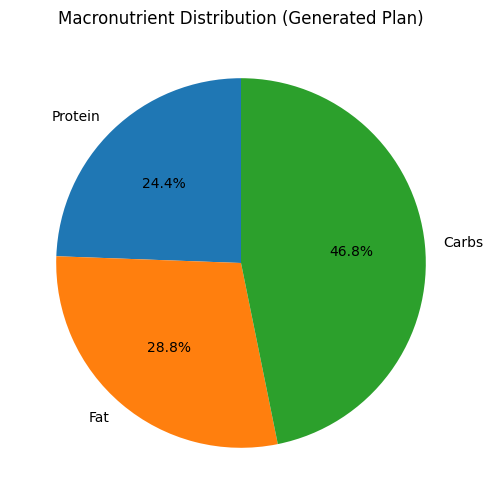

In [ ]:

def get_meals_details(recipes_df):
    meals = {}
    for _, row in recipes_df.iterrows():
       meals.update({ 
          row["Name"]:(
          row["provided_calories"],
          row["provided_protein"],
          row["provided_fat"],
          row["provided_carbs"]
       )})
    return meals

def get_macro_nutrition(meals,state):
    protein_v = 0
    fat_v = 0
    carbs_v = 0
    total_cal = 0
    for day in state:
            total_cal += meals[day[0]][0] + meals[day[1]][0] +meals[day[2]][0]
            protein_v += meals[day[0]][1] + meals[day[1]][1] +meals[day[2]][1]
            fat_v += meals[day[0]][2] + meals[day[1]][2] +meals[day[2]][2]
            carbs_v += meals[day[0]][3] + meals[day[1]][3] +meals[day[2]][3]
    return [(protein_v*4)/total_cal,(fat_v*9)/total_cal,(carbs_v*4)/total_cal]

def macro_error(meals,state):
    macros = get_macro_nutrition(meals,state)

    target = [0.4, 0.3, 0.3]  # example

    error = sum(abs(macros[i] - target[i]) for i in range(3))

    return error

def get_axis_plot(meals):
     costs = []
     errors = []
     i = 10000
     for _ in range(5):  # 30 different solution
        g = GAProblem(recipes_df,i,2000)
        solution,_ = GASearch(g)
        cost = g.get_total_cost(solution)
        error = macro_error(meals,solution)
        i += 5000 
        costs.append(cost)
        errors.append(error)
     return costs,errors

g = GAProblem(recipes_df,20000,2000)
solution, fitness  = GASearch(g)
print(solution)
print(f"Fitness: {fitness}")
print(f"total cost is : {g.get_total_cost(solution)}")
print(f"total calories are : {g.get_total_cal(solution)}")

meals_details = get_meals_details(recipes_df)
labels = ['Protein', 'Fat', 'Carbs']
values = get_macro_nutrition(meals_details,solution)
plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Macronutrient Distribution (Generated Plan)')
plt.show()

x_axis,y_axis = get_axis_plot(meals_details)
plt.figure(figsize=(7,5))
plt.scatter(x_axis, y_axis, color='blue', alpha=0.7)
plt.xlabel("Total Cost")
plt.ylabel("Nutrition Error (Macro Deviation)")
plt.title("Cost vs Nutrition Trade-off")
plt.grid(True)
plt.show()
